In [ ]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


In [2]:
SA2_PATH = Path("../data/raw/sa2_boundaries/SA2_2021_AUST_GDA2020.shp")
sa2 = gpd.read_file(SA2_PATH)
sa2.head()

,SA2_CODE21,SA2_NAME21,CHG_FLAG21,CHG_LBL21,SA3_CODE21,SA3_NAME21,SA4_CODE21,SA4_NAME21,GCC_CODE21,GCC_NAME21,STE_CODE21,STE_NAME21,AUS_CODE21,AUS_NAME21,AREASQKM21,LOCI_URI21,geometry
0,101021007,Braidwood,0,No change,10102,Queanbeyan,101,Capital Region,1RNSW,Rest of NSW,1,New South Wales,AUS,Australia,3418.3525,http://linked.data.gov.au/dataset/asgsed3/SA2/...,"POLYGON ((149.58424 -35.44426, 149.58444 -35.4..."
1,101021008,Karabar,0,No change,10102,Queanbeyan,101,Capital Region,1RNSW,Rest of NSW,1,New South Wales,AUS,Australia,6.9825,http://linked.data.gov.au/dataset/asgsed3/SA2/...,"POLYGON ((149.21899 -35.36738, 149.218 -35.366..."
2,101021009,Queanbeyan,0,No change,10102,Queanbeyan,101,Capital Region,1RNSW,Rest of NSW,1,New South Wales,AUS,Australia,4.7620,http://linked.data.gov.au/dataset/asgsed3/SA2/...,"POLYGON ((149.21326 -35.34325, 149.21619 -35.3..."
3,101021010,Queanbeyan - East,0,No change,10102,Queanbeyan,101,Capital Region,1RNSW,Rest of NSW,1,New South Wales,AUS,Australia,13.0032,http://linked.data.gov.au/dataset/asgsed3/SA2/...,"POLYGON ((149.24034 -35.34781, 149.24024 -35.3..."
4,101021012,Queanbeyan West - Jerrabomberra,0,No change,10102,Queanbeyan,101,Capital Region,1RNSW,Rest of NSW,1,New South Wales,AUS,Australia,13.6748,http://linked.data.gov.au/dataset/asgsed3/SA2/...,"POLYGON ((149.19572 -35.36126, 149.1997 -35.35..."


In [3]:
print(sa2.columns.tolist())
print(sa2.crs)
print(sa2.shape)

['SA2_CODE21', 'SA2_NAME21', 'CHG_FLAG21', 'CHG_LBL21', 'SA3_CODE21', 'SA3_NAME21', 'SA4_CODE21', 'SA4_NAME21', 'GCC_CODE21', 'GCC_NAME21', 'STE_CODE21', 'STE_NAME21', 'AUS_CODE21', 'AUS_NAME21', 'AREASQKM21', 'LOCI_URI21', 'geometry']
EPSG:7844
(2473, 17)


In [4]:
# Keep only Statistical Areas Level 2 (SA2s) in Victoria
sa2_vic = sa2[sa2["STE_CODE21"] == "2"].copy()

# Keep only the columns needed for later spatial joins
sa2_vic = sa2_vic[
    ["SA2_CODE21", "SA2_NAME21", "AREASQKM21", "geometry"]
]

sa2_vic.head()

,SA2_CODE21,SA2_NAME21,AREASQKM21,geometry
644,201011001,Alfredton,52.7109,"POLYGON ((143.78282 -37.56666, 143.75558 -37.5..."
645,201011002,Ballarat,12.3787,"POLYGON ((143.81896 -37.55582, 143.81644 -37.5..."
646,201011005,Buninyong,51.5855,"POLYGON ((143.84171 -37.61596, 143.84176 -37.6..."
647,201011006,Delacombe,34.1607,"POLYGON ((143.7505 -37.59119, 143.75044 -37.59..."
648,201011007,Smythes Creek,104.7274,"POLYGON ((143.73296 -37.62333, 143.73263 -37.6..."


Number of Victorian SA2s: 524
EPSG:7844


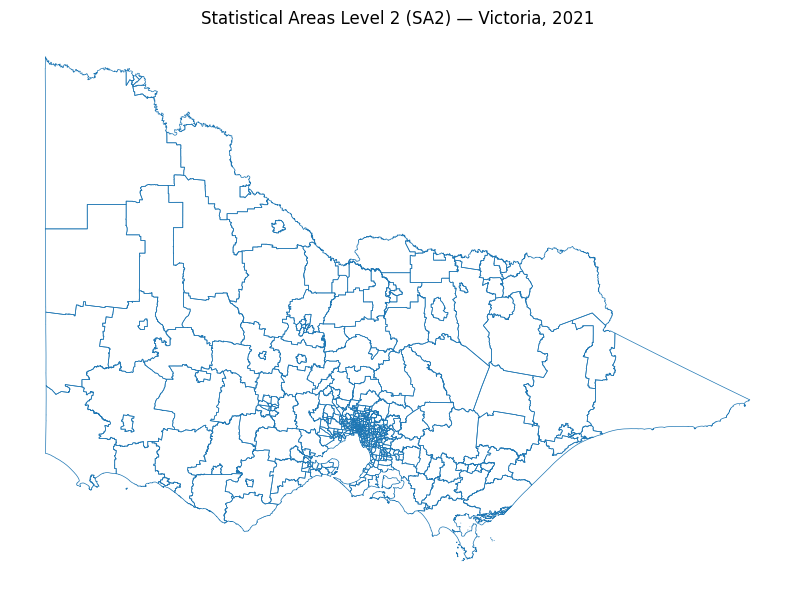

In [5]:
print(f"Number of Victorian SA2s: {len(sa2_vic)}")
print(sa2_vic.crs)

sa2_vic.head()

fig, ax = plt.subplots(figsize=(10, 10))

sa2_vic.boundary.plot(ax=ax, linewidth=0.5)

ax.set_title("Statistical Areas Level 2 (SA2) — Victoria, 2021")
ax.set_axis_off()

plt.show()

In [6]:
# Save a clean Victoria-only SA2 layer for later use
OUTPUT_PATH = Path("../data/curated/sa2_vic_2021.geojson")

sa2_vic.to_file(OUTPUT_PATH, driver="GeoJSON")

print(f"Saved to: {OUTPUT_PATH}")

Saved to: ..\data\curated\sa2_vic_2021.geojson


In [7]:
#population

POP_PATH = Path("../data/raw/abs_population/32180DS0003_2001-25.xlsx")

population_raw = pd.read_excel(
    POP_PATH,
    sheet_name="Table 1",
    header=None
)

population_raw.head(10)

,0,1,2,3,4,5,6,7,8,9,...,25,26,27,28,29,30,31,32,33,34
0,This tab has one table with the estimated resi...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,"Table 1. Estimated resident population, Statis...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,"Regional population, 2024–25",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
5,S/T code,S/T name,GCCSA code,GCCSA name,SA4 code,SA4 name,SA3 code,SA3 name,SA2 code,SA2 name,...,no.,no.,no.,no.,no.,no.,no.,no.,no.,no.
6,1,New South Wales,1RNSW,Rest of NSW,101,Capital Region,10102,Queanbeyan,101021007,Braidwood,...,3950,4041,4145,4218,4282,4332,4368,4389,4480,4494
7,1,New South Wales,1RNSW,Rest of NSW,101,Capital Region,10102,Queanbeyan,101021008,Karabar,...,8531,8530,8516,8500,8535,8548,8527,8470,8432,8409
8,1,New South Wales,1RNSW,Rest of NSW,101,Capital Region,10102,Queanbeyan,101021009,Queanbeyan,...,11230,11362,11460,11468,11460,11375,11378,11391,11344,11251
9,1,New South Wales,1RNSW,Rest of NSW,101,Capital Region,10102,Queanbeyan,101021010,Queanbeyan - East,...,4970,5016,5079,5126,5089,5097,5101,5099,5133,5111


In [9]:
population = population_raw.iloc[6:].copy()

# Rename the first 10 identifying columns
population = population.rename(columns={
    0: "STE_CODE",
    1: "STE_NAME",
    2: "GCCSA_CODE",
    3: "GCCSA_NAME",
    4: "SA4_CODE",
    5: "SA4_NAME",
    6: "SA3_CODE",
    7: "SA3_NAME",
    8: "SA2_CODE21",
    9: "SA2_NAME21"
})

# Rename population-year columns using the year row
for col in range(10, population.shape[1]):
    year = int(population_raw.iloc[4, col])
    population = population.rename(columns={col: f"POP_{year}"})

population.head()

population_vic = population[
    population["STE_CODE"].astype(str) == "2"
].copy()

population_vic.head()

print(f"Victorian SA2 population rows: {len(population_vic)}")

population_vic[
    ["SA2_CODE21", "SA2_NAME21", "POP_2021", "POP_2024", "POP_2025"]
].head()

matched = sa2_vic.merge(
    population_vic[
        ["SA2_CODE21", "SA2_NAME21", "POP_2021", "POP_2024", "POP_2025"]
    ],
    on="SA2_CODE21",
    how="left",
    suffixes=("_boundary", "_population")
)

print("Total Victorian SA2 boundaries:", len(sa2_vic))
print("Population matches:", matched["POP_2025"].notna().sum())
print("Missing population matches:", matched["POP_2025"].isna().sum())

Victorian SA2 population rows: 522
Total Victorian SA2 boundaries: 524
Population matches: 0
Missing population matches: 524


In [10]:
print(sa2_vic["SA2_CODE21"].dtype)
print(population_vic["SA2_CODE21"].dtype)

print(sa2_vic["SA2_CODE21"].head().tolist())
print(population_vic["SA2_CODE21"].head().tolist())

sa2_vic["SA2_CODE21"] = (
    sa2_vic["SA2_CODE21"]
    .astype(str)
    .str.strip()
    .str.replace(r"\.0$", "", regex=True)
)

population_vic["SA2_CODE21"] = (
    population_vic["SA2_CODE21"]
    .astype(str)
    .str.strip()
    .str.replace(r"\.0$", "", regex=True)
)

matched = sa2_vic.merge(
    population_vic[
        ["SA2_CODE21", "SA2_NAME21", "POP_2021", "POP_2024", "POP_2025"]
    ],
    on="SA2_CODE21",
    how="left",
    suffixes=("_boundary", "_population")
)

print("Total Victorian SA2 boundaries:", len(sa2_vic))
print("Population matches:", matched["POP_2025"].notna().sum())
print("Missing population matches:", matched["POP_2025"].isna().sum())

object
object
['201011001', '201011002', '201011005', '201011006', '201011007']
[201011001, 201011002, 201011005, 201011006, 201011007]
Total Victorian SA2 boundaries: 524
Population matches: 522
Missing population matches: 2


In [11]:
# ============================================================
# Validate and clean Victorian SA2 population data
# ============================================================

# 1. Inspect SA2s in the boundary file with no 2025 population match
missing_sa2 = matched.loc[
    matched["POP_2025"].isna(),
    ["SA2_CODE21", "SA2_NAME21_boundary"]
]

print("SA2s with missing population:")
display(missing_sa2)


# 2. Check whether the population dataset contains any SA2 codes
#    that are not present in our Victorian boundary file
boundary_codes = set(sa2_vic["SA2_CODE21"])
population_codes = set(population_vic["SA2_CODE21"])

population_only = population_codes - boundary_codes

print("\nPopulation-only SA2 codes:")
print(population_only)


# 3. Keep the population variables useful for the project
population_clean = population_vic[
    [
        "SA2_CODE21",
        "SA2_NAME21",
        "POP_2021",
        "POP_2022",
        "POP_2023",
        "POP_2024",
        "POP_2025"
    ]
].copy()


# 4. Make sure population columns are numeric
population_columns = [
    "POP_2021",
    "POP_2022",
    "POP_2023",
    "POP_2024",
    "POP_2025"
]

population_clean[population_columns] = population_clean[
    population_columns
].apply(pd.to_numeric, errors="coerce")


# 5. Calculate recent population growth (2021 → 2025)
population_clean["POP_GROWTH_2021_2025"] = (
    population_clean["POP_2025"] / population_clean["POP_2021"] - 1
)


# 6. Final validation
print("\n--- Population dataset summary ---")
print("Victorian population SA2s:", len(population_clean))
print("Unique SA2 codes:", population_clean["SA2_CODE21"].nunique())
print("Missing 2025 population values:", population_clean["POP_2025"].isna().sum())
print("Missing growth values:", population_clean["POP_GROWTH_2021_2025"].isna().sum())


# 7. Preview final cleaned population data
display(population_clean.head())

SA2s with missing population:


,SA2_CODE21,SA2_NAME21_boundary
522,297979799,Migratory - Offshore - Shipping (Vic.)
523,299999499,No usual address (Vic.)



Population-only SA2 codes:
set()

--- Population dataset summary ---
Victorian population SA2s: 522
Unique SA2 codes: 522
Missing 2025 population values: 0
Missing growth values: 4


,SA2_CODE21,SA2_NAME21,POP_2021,POP_2022,POP_2023,POP_2024,POP_2025,POP_GROWTH_2021_2025
648,201011001,Alfredton,16841,17988,18966,20082,20825,0.236566
649,201011002,Ballarat,12071,11907,11769,11714,11668,-0.033386
650,201011005,Buninyong,7229,7232,7299,7320,7384,0.021441
651,201011006,Delacombe,10648,11769,12824,14218,15255,0.432663
652,201011007,Smythes Creek,4211,4205,4249,4255,4250,0.009261


In [12]:
# Inspect SA2s where 2021–2025 population growth could not be calculated
missing_growth = population_clean.loc[
    population_clean["POP_GROWTH_2021_2025"].isna(),
    [
        "SA2_CODE21",
        "SA2_NAME21",
        "POP_2021",
        "POP_2022",
        "POP_2023",
        "POP_2024",
        "POP_2025"
    ]
]

print("SA2s with missing population growth:")
display(missing_growth)

SA2s with missing population growth:


,SA2_CODE21,SA2_NAME21,POP_2021,POP_2022,POP_2023,POP_2024,POP_2025
733,205021080,Alps - East,0,0,0,0,0
736,205021083,Lake King,0,0,0,0,0
782,206041127,West Melbourne - Industrial,0,0,0,0,0
787,206041507,Royal Botanic Gardens Victoria,0,0,0,0,0


In [13]:
# ============================================================
# Finalise and save Victorian SA2 population data
# ============================================================

# Growth remains NaN where the 2021 population is zero,
# because percentage growth from a zero base is undefined.

OUTPUT_POP = Path("../data/curated/sa2_population_2021_2025.parquet")

population_clean.to_parquet(
    OUTPUT_POP,
    index=False
)

print(f"Saved population data to: {OUTPUT_POP}")
print(f"Rows saved: {len(population_clean)}")
print(f"Unique SA2s: {population_clean['SA2_CODE21'].nunique()}")
print(f"SA2s with undefined growth due to zero population: "
      f"{population_clean['POP_GROWTH_2021_2025'].isna().sum()}")

display(population_clean.head())

Saved population data to: ..\data\curated\sa2_population_2021_2025.parquet
Rows saved: 522
Unique SA2s: 522
SA2s with undefined growth due to zero population: 4


,SA2_CODE21,SA2_NAME21,POP_2021,POP_2022,POP_2023,POP_2024,POP_2025,POP_GROWTH_2021_2025
648,201011001,Alfredton,16841,17988,18966,20082,20825,0.236566
649,201011002,Ballarat,12071,11907,11769,11714,11668,-0.033386
650,201011005,Buninyong,7229,7232,7299,7320,7384,0.021441
651,201011006,Delacombe,10648,11769,12824,14218,15255,0.432663
652,201011007,Smythes Creek,4211,4205,4249,4255,4250,0.009261


In [14]:
# ============================================================
# ABS Personal Income — SA2, 2018-19 to 2022-23
# ============================================================

INCOME_PATH = Path(
    "../data/raw/abs_income/"
    "Table 1 - Total income, earners and summary statistics by geography, "
    "2018-19 to 2022-23.xlsx"
)

# Table 1.4 contains Statistical Area Level 2 (SA2) data
income_raw = pd.read_excel(
    INCOME_PATH,
    sheet_name="Table 1.4",
    header=None
)

# Data begins at row 7
income = income_raw.iloc[7:].copy()

# Relevant columns:
# 0  = SA2 code
# 1  = SA2 name
# 2-6 = number of earners (2018-19 to 2022-23)
# 17-21 = median total income (2018-19 to 2022-23)
# 22-26 = mean total income (2018-19 to 2022-23)

income = income.rename(columns={
    0: "SA2_CODE21",
    1: "SA2_NAME21",
    2: "EARNERS_2018_19",
    3: "EARNERS_2019_20",
    4: "EARNERS_2020_21",
    5: "EARNERS_2021_22",
    6: "EARNERS_2022_23",
    17: "MEDIAN_INCOME_2018_19",
    18: "MEDIAN_INCOME_2019_20",
    19: "MEDIAN_INCOME_2020_21",
    20: "MEDIAN_INCOME_2021_22",
    21: "MEDIAN_INCOME_2022_23",
    22: "MEAN_INCOME_2018_19",
    23: "MEAN_INCOME_2019_20",
    24: "MEAN_INCOME_2020_21",
    25: "MEAN_INCOME_2021_22",
    26: "MEAN_INCOME_2022_23"
})

# Keep only useful variables
income = income[
    [
        "SA2_CODE21",
        "SA2_NAME21",
        "EARNERS_2022_23",
        "MEDIAN_INCOME_2018_19",
        "MEDIAN_INCOME_2019_20",
        "MEDIAN_INCOME_2020_21",
        "MEDIAN_INCOME_2021_22",
        "MEDIAN_INCOME_2022_23",
        "MEAN_INCOME_2022_23"
    ]
].copy()

# Standardise SA2 code for joining
income["SA2_CODE21"] = (
    income["SA2_CODE21"]
    .astype(str)
    .str.strip()
    .str.replace(r"\.0$", "", regex=True)
)

# Keep Victoria.
# Victorian SA2 codes begin with 2.
income_vic = income[
    income["SA2_CODE21"].str.match(r"^2\d{8}$", na=False)
].copy()

# Convert income variables to numeric
numeric_cols = [
    "EARNERS_2022_23",
    "MEDIAN_INCOME_2018_19",
    "MEDIAN_INCOME_2019_20",
    "MEDIAN_INCOME_2020_21",
    "MEDIAN_INCOME_2021_22",
    "MEDIAN_INCOME_2022_23",
    "MEAN_INCOME_2022_23"
]

income_vic[numeric_cols] = income_vic[numeric_cols].apply(
    pd.to_numeric,
    errors="coerce"
)

# Check compatibility with our Victorian SA2 boundaries
income_matched = sa2_vic.merge(
    income_vic,
    on="SA2_CODE21",
    how="left",
    suffixes=("_boundary", "_income")
)

print("--- Income dataset summary ---")
print("Victorian SA2 boundaries:", len(sa2_vic))
print("Victorian income SA2s:", len(income_vic))
print(
    "Income matches:",
    income_matched["MEDIAN_INCOME_2022_23"].notna().sum()
)
print(
    "Missing income matches:",
    income_matched["MEDIAN_INCOME_2022_23"].isna().sum()
)

# Show any boundary SA2s without income
missing_income = income_matched.loc[
    income_matched["MEDIAN_INCOME_2022_23"].isna(),
    ["SA2_CODE21", "SA2_NAME21_boundary"]
]

print("\nSA2s with missing income:")
display(missing_income)

# Preview cleaned income data
display(income_vic.head())

--- Income dataset summary ---
Victorian SA2 boundaries: 524
Victorian income SA2s: 522
Income matches: 520
Missing income matches: 4

SA2s with missing income:


,SA2_CODE21,SA2_NAME21_boundary
85,205021080,Alps - East
88,205021083,Lake King
522,297979799,Migratory - Offshore - Shipping (Vic.)
523,299999499,No usual address (Vic.)


,SA2_CODE21,SA2_NAME21,EARNERS_2022_23,MEDIAN_INCOME_2018_19,MEDIAN_INCOME_2019_20,MEDIAN_INCOME_2020_21,MEDIAN_INCOME_2021_22,MEDIAN_INCOME_2022_23,MEAN_INCOME_2022_23
652,201011001,Alfredton,11963.0,51620.0,52777.0,55499.0,58316.0,60841.0,72489.0
653,201011002,Ballarat,8186.0,51187.0,50968.0,53232.0,55618.0,58553.0,86356.0
654,201011005,Buninyong,4731.0,49846.0,51572.0,53959.0,55278.0,57501.0,70993.0
655,201011006,Delacombe,8047.0,47940.0,49810.0,51041.0,53390.0,56390.0,62175.0
656,201011007,Smythes Creek,2857.0,50938.0,52364.0,55547.0,55423.0,55311.0,66903.0


In [15]:
# ============================================================
# Finalise and save Victorian SA2 income data
# ============================================================

# Keep the cleaned Victorian SA2 income dataset.
# Missing income for non-residential / zero-population SA2s is
# intentionally left as missing rather than imputed.

income_clean = income_vic[
    [
        "SA2_CODE21",
        "SA2_NAME21",
        "EARNERS_2022_23",
        "MEDIAN_INCOME_2018_19",
        "MEDIAN_INCOME_2019_20",
        "MEDIAN_INCOME_2020_21",
        "MEDIAN_INCOME_2021_22",
        "MEDIAN_INCOME_2022_23",
        "MEAN_INCOME_2022_23"
    ]
].copy()

# Save cleaned SA2 income data
OUTPUT_INCOME = Path(
    "../data/curated/sa2_income_2018_19_to_2022_23.parquet"
)

income_clean.to_parquet(
    OUTPUT_INCOME,
    index=False
)

print("--- Final income dataset ---")
print(f"Saved to: {OUTPUT_INCOME}")
print(f"Rows saved: {len(income_clean)}")
print(f"Unique SA2s: {income_clean['SA2_CODE21'].nunique()}")
print(
    "SA2s with usable 2022-23 median income:",
    income_clean["MEDIAN_INCOME_2022_23"].notna().sum()
)
print(
    "SA2s with missing 2022-23 median income:",
    income_clean["MEDIAN_INCOME_2022_23"].isna().sum()
)

display(income_clean.head())

--- Final income dataset ---
Saved to: ..\data\curated\sa2_income_2018_19_to_2022_23.parquet
Rows saved: 522
Unique SA2s: 522
SA2s with usable 2022-23 median income: 520
SA2s with missing 2022-23 median income: 2


,SA2_CODE21,SA2_NAME21,EARNERS_2022_23,MEDIAN_INCOME_2018_19,MEDIAN_INCOME_2019_20,MEDIAN_INCOME_2020_21,MEDIAN_INCOME_2021_22,MEDIAN_INCOME_2022_23,MEAN_INCOME_2022_23
652,201011001,Alfredton,11963.0,51620.0,52777.0,55499.0,58316.0,60841.0,72489.0
653,201011002,Ballarat,8186.0,51187.0,50968.0,53232.0,55618.0,58553.0,86356.0
654,201011005,Buninyong,4731.0,49846.0,51572.0,53959.0,55278.0,57501.0,70993.0
655,201011006,Delacombe,8047.0,47940.0,49810.0,51041.0,53390.0,56390.0,62175.0
656,201011007,Smythes Creek,2857.0,50938.0,52364.0,55547.0,55423.0,55311.0,66903.0
